## import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
from keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.metrics import confusion_matrix, classification_report

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## data Analysis


In [ ]:
df = pd.read_csv('/content/emotion_sentimen_dataset.csv')

df = df[df['Emotion'].notna()].reset_index(drop=True)

df = df.sample(80000, random_state=42).reset_index(drop=True)

print(df.shape)


(80000, 3)


In [ ]:

print(df.shape)
print(df.head())
print(df.tail())


(80000, 3)
   Unnamed: 0                                               text     Emotion
0      388803  i do feel like i am alot more outgoing then i ...     neutral
1       79052  i go back and face the home in that ruined sta...     neutral
2      736807          i feel the amount allocated is inadequate     neutral
3      114142  im feeling very mellow and affectionate right now        love
4       64730  i feel their anticipation on the update and i ...  enthusiasm
       Unnamed: 0                                               text  Emotion
79995      144629  i feel like a lot of people contributed a lot ...  neutral
79996      117013  i feel sentimental towards my moms promise and...  neutral
79997      409654  i feel hated my friend sean delated me as a fr...     hate
79998       66059  i feel so much better in myself for a week of ...  neutral
79999      789699  i feel so mentally anguished and most of it is...  neutral


In [ ]:
print(df['Emotion'].value_counts(dropna=False))


Emotion
neutral       64329
love           3830
happiness      2544
sadness        1664
relief         1589
hate           1437
anger          1171
fun             953
enthusiasm      887
surprise        627
empty           537
worry           420
boredom          12
Name: count, dtype: int64


In [ ]:
df.sample(10)

,Unnamed: 0,text,Emotion
76141,421659,i left jerusalem feeling confused,neutral
15663,239632,i am already feeling rather gloomy sitting her...,neutral
26349,670089,i just feel that i should share this to all of...,neutral
67249,496181,i feel very loved and truly thank everyone who...,love
42769,558979,i realised that this was no longer the truth i...,neutral
44091,157603,im feeling a bout of pms coming on so am just ...,neutral
13300,216853,i feel most furious about though is that max i...,neutral
67912,483392,i screw up all the time but i know im loved ev...,love
73635,225087,im getting an awful feeling that im soon going...,neutral
57257,5667,i hate when im refered to that game guitar her...,hate


In [ ]:
df['Emotion'].unique()

array(['neutral', 'love', 'enthusiasm', 'relief', 'sadness', 'empty',
       'happiness', 'fun', 'surprise', 'hate', 'anger', 'boredom',
       'worry'], dtype=object)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# removing the duplicates
df = df.drop_duplicates()

In [ ]:
df.shape

(80000, 3)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
text,0
Emotion,0


In [ ]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
# Drop very small or unwanted emotion classes
drop_classes = ['surprise', 'empty', 'worry', 'boredom']
df = df[~df['Emotion'].isin(drop_classes)].reset_index(drop=True)

print("After dropping rare classes:")
print(df['Emotion'].value_counts())

# Undersample the 'neutral' class to reduce imbalance
max_neutral = 3500  # target size for neutral

neutral_df = df[df['Emotion'] == 'neutral'].sample(
    n=min(max_neutral, df['Emotion'].value_counts()['neutral']),
    random_state=42
)
other_df = df[df['Emotion'] != 'neutral']

df = pd.concat([neutral_df, other_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing neutral:")
print(df['Emotion'].value_counts())


After dropping rare classes:
Emotion
neutral       64329
love           3830
happiness      2544
sadness        1664
relief         1589
hate           1437
anger          1171
fun             953
enthusiasm      887
Name: count, dtype: int64

After balancing neutral:
Emotion
love          3830
neutral       3500
happiness     2544
sadness       1664
relief        1589
hate          1437
anger         1171
fun            953
enthusiasm     887
Name: count, dtype: int64


In [ ]:
df.sample(10)

,text,Emotion
16417,i didn t quite feel outraged but i did feel in...,anger
16885,i felt really good after my workout and cardio...,happiness
15463,i can feel this really effecting my attitude t...,anger
4466,i feel anxious and sometimes angry because i d...,anger
5960,i also feel ashamed at the hurt caused and ash...,hate
14506,i feel the sites honesty and user friendly app...,neutral
1369,i was just now looking through the comments ma...,anger
9345,i want every woman to feel the kind of love fr...,love
5958,i used to be the self righteous christian that...,anger
14126,i generally like nivea products but this gel c...,neutral


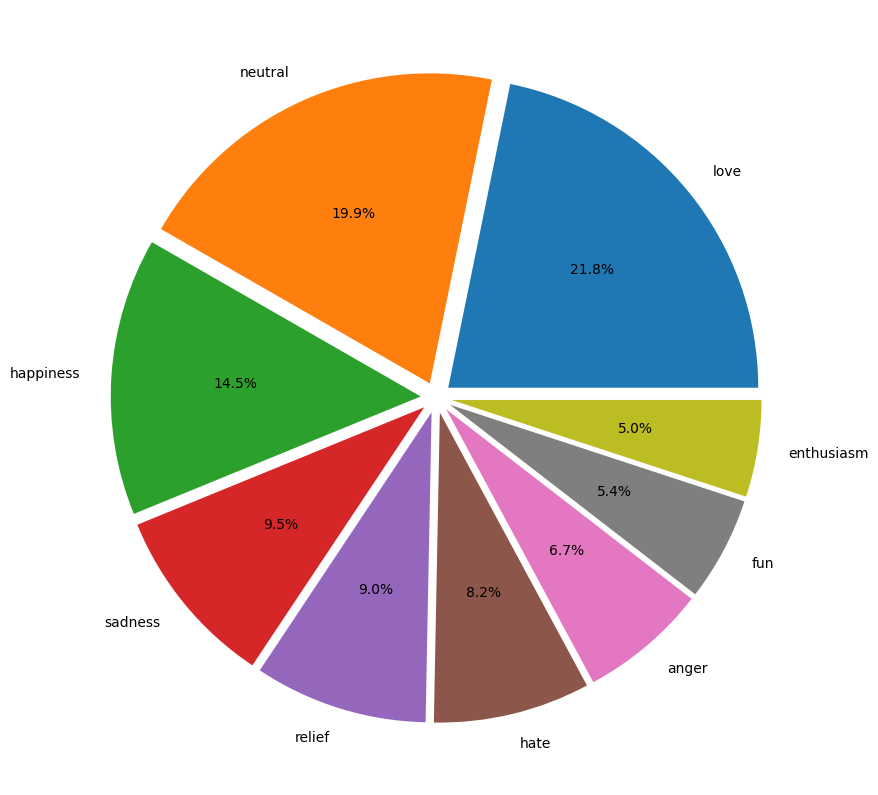

In [ ]:
value_counts = df['Emotion'].value_counts()
plt.figure(figsize=(10,18))
plt.xticks(rotation=75)  # Rotating x-axis labels for better visibility
plt.pie(value_counts.values, labels=value_counts.index,explode=[0.05]*df['Emotion'].nunique(),autopct='%1.1f%%')
plt.show()

##PREPROCESSING

In [ ]:
# Define a dictionary of chat word mappings
# Chat words are informal expressions used in online communication, like "lol"
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [ ]:
# Convert all chat word keys to lowercase for case-insensitive matching
chat_words = {key.lower(): value for key, value in chat_words.items()}

# Function to replace chat words with their full forms
def replace_chat_words(text):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in chat_words:
            words[i] = chat_words[word.lower()]
    return ' '.join(words)

# Apply to the text column
df['text'] = df['text'].apply(replace_chat_words)


In [ ]:
# Remove all characters except alphabets and spaces
df['text'] = df['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
df.head()


,text,Emotion
0,i remember feeling really excited yet slightly...,enthusiasm
1,i feel such eagerness and pleasure in the last...,enthusiasm
2,i would love to have more but after three extr...,love
3,i love the feeling of when someone else thinks...,love
4,i affirm for instance my wish for inner conten...,happiness


In [ ]:
stop = stopwords.words('english')
stop = set([word.lower() for word in stop])  # ensure lowercase

df["text"] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop])
)
df.head()


,text,Emotion
0,remember feeling really excited yet slightly b...,enthusiasm
1,feel eagerness pleasure last three days school...,enthusiasm
2,would love three extremely hard complicated pr...,love
3,love feeling someone else thinks drawing amazi...,love
4,affirm instance wish inner contentment moment ...,happiness


In [ ]:
df['text'] = df['text'].str.lower()
print(df.head())

                                                text     Emotion
0  remember feeling really excited yet slightly b...  enthusiasm
1  feel eagerness pleasure last three days school...  enthusiasm
2  would love three extremely hard complicated pr...        love
3  love feeling someone else thinks drawing amazi...        love
4  affirm instance wish inner contentment moment ...   happiness


In [ ]:
# Remove numerical digits from text
df['text'] = df['text'].str.replace(r'\d+', '', regex=True)
df.head()


,text,Emotion
0,remember feeling really excited yet slightly b...,enthusiasm
1,feel eagerness pleasure last three days school...,enthusiasm
2,would love three extremely hard complicated pr...,love
3,love feeling someone else thinks drawing amazi...,love
4,affirm instance wish inner contentment moment ...,happiness


In [ ]:
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True) #Removing white spaces
print(df.head())

                                                text     Emotion
0  remember feeling really excited yet slightly b...  enthusiasm
1  feel eagerness pleasure last three days school...  enthusiasm
2  would love three extremely hard complicated pr...        love
3  love feeling someone else thinks drawing amazi...        love
4  affirm instance wish inner contentment moment ...   happiness


In [ ]:
df['text'] = df['text'].str.replace(r'http\S+', '', regex=True) #REMOVING URLS
print(df.head())

                                                text     Emotion
0  remember feeling really excited yet slightly b...  enthusiasm
1  feel eagerness pleasure last three days school...  enthusiasm
2  would love three extremely hard complicated pr...        love
3  love feeling someone else thinks drawing amazi...        love
4  affirm instance wish inner contentment moment ...   happiness


## data Prepration


In [ ]:
df.sample(10)

,text,Emotion
13280,really like vibrant fun colour feeling optimis...,fun
9000,longer feeling nervous surgery excited aj quie...,enthusiasm
17169,feel angry also feel hurt wasted,anger
859,loved mix people feel glad new people came alo...,love
6085,feel ok others real struggle barely get bed,neutral
16065,want enjoy feel successful,happiness
16983,remember things love feel unloved,love
10451,could feel summer losing battle fact admired l...,neutral
13756,feel fine remaster help,neutral
3688,ready feel sadness tragic scenes fresh katrina...,sadness


In [ ]:
df['Emotion'].unique()

array(['enthusiasm', 'love', 'happiness', 'relief', 'anger', 'hate',
       'neutral', 'fun', 'sadness'], dtype=object)

In [ ]:
# Remove 'boredom' because it has too few samples to model reliably
df = df[df['Emotion'] != 'boredom'].reset_index(drop=True)

print("After removing 'boredom':")
print(df['Emotion'].value_counts())


After removing 'boredom':
Emotion
love          3830
neutral       3500
happiness     2544
sadness       1664
relief        1589
hate          1437
anger         1171
fun            953
enthusiasm     887
Name: count, dtype: int64


In [ ]:
print("Final Emotion counts:")
print(df['Emotion'].value_counts())


Final Emotion counts:
Emotion
love          3830
neutral       3500
happiness     2544
sadness       1664
relief        1589
hate          1437
anger         1171
fun            953
enthusiasm     887
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df['text']
y = df['Emotion']   # no mapping now

le = LabelEncoder()
y = le.fit_transform(y)

print("Label classes:", le.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Label classes: ['anger' 'enthusiasm' 'fun' 'happiness' 'hate' 'love' 'neutral' 'relief'
 'sadness']
Train: (12302,)
Val: (2636,)
Test: (2637,)


In [ ]:
# Tokenizer: fit only on training data
max_words = 60000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences   = tokenizer.texts_to_sequences(X_val)
X_test_sequences  = tokenizer.texts_to_sequences(X_test)

# Maximum sequence length based on training data
maxlen = max(len(tokens) for tokens in X_train_sequences)
print("Maximum sequence length (maxlen):", maxlen)

# Pad all sets to the same length
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_val_padded   = pad_sequences(X_val_sequences,   maxlen=maxlen, padding='post')
X_test_padded  = pad_sequences(X_test_sequences,  maxlen=maxlen, padding='post')

print("X_train_padded shape:", X_train_padded.shape)
print("X_val_padded shape:  ", X_val_padded.shape)
print("X_test_padded shape: ", X_test_padded.shape)

# Embedding input size (vocabulary size)
input_size = min(max_words, len(tokenizer.word_index) + 1)
print("Embedding input_size:", input_size)


Maximum sequence length (maxlen): 39
X_train_padded shape: (12302, 39)
X_val_padded shape:   (2636, 39)
X_test_padded shape:  (2637, 39)
Embedding input_size: 13530


## Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization

num_classes = len(le.classes_)  # should be 8

model = Sequential()

# Embedding layer: input_size from tokenizer, sequence length = maxlen (33)
model.add(Embedding(input_dim=input_size, output_dim=100, input_length=maxlen))

# Bi-LSTM layers
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(64)))

# Regularization
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Dense layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output layer: 8 emotion classes
model.add(Dense(num_classes, activation='softmax'))

# Build the model before summary
model.build(input_shape=(None, maxlen))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 39, 100)        │     1,353,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 39, 256)        │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761,201 (6.72 MB)

 Trainable params: 1,760,945 (6.72 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [ ]:
# Early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_padded, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4062 - loss: 1.6531 - val_accuracy: 0.7132 - val_loss: 1.3529
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9008 - loss: 0.3468 - val_accuracy: 0.7591 - val_loss: 0.6566
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9619 - loss: 0.1459 - val_accuracy: 0.9294 - val_loss: 0.2654
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9814 - loss: 0.0629 - val_accuracy: 0.9241 - val_loss: 0.3437
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9857 - loss: 0.0568 - val_accuracy: 0.9249 - val_loss: 0.3007
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9894 - loss: 0.0389 - val_accuracy: 0.9029 - val_loss: 0.5074


In [ ]:
import numpy as np

matches = 0
for i in range(300):
    if np.array_equal(X_train_padded[i], X_val_padded[i]):
        matches += 1

print("Identical rows train↔val:", matches)


Identical rows train↔val: 0


In [ ]:
import numpy as np

unique, counts = np.unique(y_val, return_counts=True)
print(dict(zip(le.inverse_transform(unique), counts)))


{'anger': np.int64(176), 'enthusiasm': np.int64(133), 'fun': np.int64(143), 'happiness': np.int64(381), 'hate': np.int64(216), 'love': np.int64(574), 'neutral': np.int64(525), 'relief': np.int64(239), 'sadness': np.int64(249)}


In [ ]:
import numpy as np

print("Train shape:", X_train_padded.shape)
print("Val shape:", X_val_padded.shape)

# Check if any rows are exactly identical between train and val
matches = 0
for i in range(10):
    if np.array_equal(X_train_padded[i], X_val_padded[i]):
        matches += 1
print("First 10 train rows identical to val?:", matches > 0)


Train shape: (12302, 39)
Val shape: (2636, 39)
First 10 train rows identical to val?: False


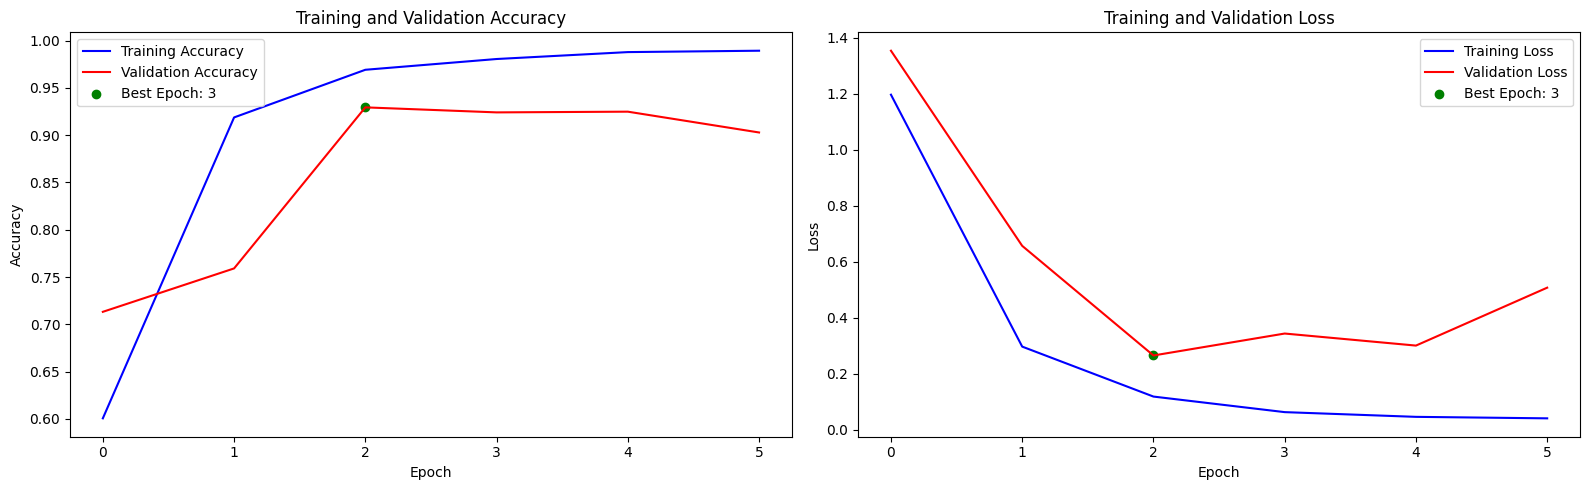

In [ ]:


# Get the epoch with the highest validation accuracy
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

# Create a subplot with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Plot training and validation accuracy
axs[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
axs[0].scatter(best_epoch - 1, history.history['val_accuracy'][best_epoch - 1], color='green', label=f'Best Epoch: {best_epoch}')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()

# Plot training and validation loss
axs[1].plot(history.history['loss'], label='Training Loss', color='blue')
axs[1].plot(history.history['val_loss'], label='Validation Loss', color='red')
axs[1].scatter(best_epoch - 1, history.history['val_loss'][best_epoch - 1], color='green',label=f'Best Epoch: {best_epoch}')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_padded, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)


Test accuracy: 0.9287068843841553
Test loss: 0.26331502199172974


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))


83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

       anger       0.99      0.82      0.90       176
  enthusiasm       0.80      0.97      0.87       133
         fun       0.70      0.95      0.80       143
   happiness       0.94      0.96      0.95       382
        hate       1.00      0.87      0.93       215
        love       0.97      0.98      0.97       575
     neutral       0.93      0.88      0.90       525
      relief       0.95      0.95      0.95       238
     sadness       0.99      0.94      0.97       250

    accuracy                           0.93      2637
   macro avg       0.92      0.92      0.92      2637
weighted avg       0.94      0.93      0.93      2637



In [ ]:
import pickle
from tensorflow.keras.models import load_model

# 1. Save the trained model
model.save("emotion_bilstm_model.h5")
print("Model saved as emotion_bilstm_model.h5")

# 2. Save the tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved as tokenizer.pkl")

# 3. Save the label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("Label encoder saved as label_encoder.pkl")

# 4. Save the maxlen (sequence length)
with open("maxlen.pkl", "wb") as f:
    pickle.dump(maxlen, f)
print("Maxlen saved as maxlen.pkl")


Model saved as emotion_bilstm_model.h5
Tokenizer saved as tokenizer.pkl
Label encoder saved as label_encoder.pkl
Maxlen saved as maxlen.pkl


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

import pickle
from tensorflow import keras
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
from sklearn.metrics import (
    r2_score,
    explained_variance_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
recipes_df = pd.read_csv("/content/RAW_recipes.csv")
reviews_df = pd.read_csv("/content/RAW_interactions.csv")

In [ ]:
recipes_df = recipes_df.rename(columns={'id': 'recipe_id'})
recipes_df['nutrition'] = recipes_df['nutrition'].apply(eval)

nutrition_columns = ['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)',
                     'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']
recipes_df[nutrition_columns] = pd.DataFrame(recipes_df['nutrition'].tolist(), index=recipes_df.index)
recipes_df = recipes_df.drop(['nutrition'], axis=1).drop_duplicates()

# Filter invalid rows
recipes_df_filtered = recipes_df[(recipes_df['calories'] != 0) &
                                 (recipes_df['minutes'] != 0) &
                                 (recipes_df['n_steps'] != 0)]
recipes_df_filtered = recipes_df_filtered[(recipes_df_filtered[nutrition_columns] != 0).any(axis=1)]

# Merge reviews
reviews_df_filtered = reviews_df[reviews_df['rating'] != 0]
merged_df = pd.merge(recipes_df_filtered, reviews_df_filtered, on='recipe_id', how='inner')

# Aggregate ratings
agg_data = merged_df.groupby('recipe_id').agg(
    mean_rating=('rating', 'mean'),
    review=('review', 'first')
).reset_index()

df1 = pd.merge(recipes_df_filtered, agg_data, on='recipe_id', how='inner')

In [ ]:

df1['rating_bin'] = (df1['mean_rating'] * 2).round() / 2  # creates bins like 3.0, 3.5, 4.0, etc.

n_total = 4000
bins = df1['rating_bin'].unique()
n_bins = len(bins)
samples_per_bin = n_total // n_bins

# Sample evenly from each bin (with min to avoid over-sampling small bins)
balanced_samples = []
for bin_val in bins:
    bin_data = df1[df1['rating_bin'] == bin_val]
    n_sample = min(samples_per_bin, len(bin_data))
    sampled = bin_data.sample(n=n_sample, random_state=42)
    balanced_samples.append(sampled)

df2 = pd.concat(balanced_samples, ignore_index=True)

# If got fewer than 4000 due to small bins, top up randomly
remaining = 4000 - len(df2)
if remaining > 0:
    rest = df1[~df1.index.isin(df2.index)].sample(n=remaining, random_state=42)
    df2 = pd.concat([df2, rest], ignore_index=True)

# Final shuffle
df2 = df2.sample(frac=1, random_state=42).reset_index(drop=True)



In [ ]:
df2.head()

,name,recipe_id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,...,calories,total fat (PDV),sugar (PDV),sodium (PDV),protein (PDV),saturated fat (PDV),carbohydrates (PDV),mean_rating,review,rating_bin
0,hot mint chocolate,147537,10,224740,2005-12-06,"['15-minutes-or-less', 'time-to-make', 'course...",3,['add the chocolate powder and mint chocolate ...,"like hot chocolate, but want to spice it up a ...","['cocoa powder', 'chocolate-covered mint candi...",...,76.4,3.0,32.0,2.0,12.0,6.0,3.0,4.333333,This is tasty and comforting on a chilly day! ...,4.5
1,soup in a pumpkin,42542,145,26584,2002-10-07,"['weeknight', 'time-to-make', 'course', 'main-...",14,"['preheat oven to 350 degrees', 'cut the top o...",i got this out of the paper some years ago. it...,"['pumpkin', 'chicken broth', 'heavy cream', 'f...",...,307.5,32.0,1.0,19.0,25.0,62.0,5.0,2.500000,I did not like this at all.,2.5
2,rigatoni con pepperoni,235271,20,57400,2007-06-16,"['30-minutes-or-less', 'time-to-make', 'course...",4,['heat frying pan and saute garlic and onion i...,i've had this recipe for many years and enjoy ...,"['garlic clove', 'yellow onion', 'olive oil', ...",...,1220.7,115.0,31.0,85.0,82.0,140.0,31.0,4.500000,We loved this wonderful rigatoni! The sauce c...,4.5
3,basil vinaigrette,423113,15,444132,2010-05-04,"['15-minutes-or-less', 'time-to-make', 'course...",3,"['combine all of the ingredients , except oil ...","from rebar cookbook, this is a very versatile ...","['garlic cloves', 'dijon mustard', 'honey', 'r...",...,351.9,50.0,22.0,72.0,12.0,20.0,4.0,5.000000,DH is big on Italian dressing but I like to mi...,5.0
4,smoked cornbread,508147,45,1800057891,2013-10-22,"['60-minutes-or-less', 'time-to-make', 'cuisin...",9,"[""melt 1 tbsp of butter in a small pan and sau...","smoked cheddar cheese, smoked paprika and fres...","['cake flour', 'yellow cornmeal', 'baking powd...",...,1059.1,79.0,13.0,61.0,65.0,148.0,40.0,1.000000,This didn&#039;t work out for me at all. I re...,1.0


Prepare Data

In [ ]:

# 1. Load the trained model
model = load_model("emotion_bilstm_model.h5")

# 2. Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# 3. Load label encoder
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# 4. Load maxlen
with open("maxlen.pkl", "rb") as f:
    maxlen = pickle.load(f)



def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text


def predict_emotion(text):
      # Clean text
    cleaned_text = clean_text(text)

    # Convert to sequence
    seq = tokenizer.texts_to_sequences([cleaned_text])

    # Pad
    padded = pad_sequences(seq, maxlen=maxlen, padding='post')

    # Predict
    pred = model.predict(padded)
    class_index = np.argmax(pred)

    # Convert index to label
    emotion = label_encoder.inverse_transform([class_index])[0]
    return emotion


In [ ]:


# Predict emotion for each recipe using trained sentiment model
df2['emotion'] = df2['review'].fillna("").apply(predict_emotion)

emotion_encoder = LabelEncoder()
df2['emotion_label'] = emotion_encoder.fit_transform(df2['emotion'])

emotion_onehot = tf.keras.utils.to_categorical(df2['emotion_label'], num_classes=12)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━

In [ ]:
# Normalize nutrition
scaler = MinMaxScaler()
df2[nutrition_columns] = scaler.fit_transform(df2[nutrition_columns])

In [ ]:
df2['text_data'] = df2['ingredients'] + " " + df2['steps']

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df2['text_data'])
seqs = tokenizer.texts_to_sequences(df2['text_data'])
padded_seq = pad_sequences(seqs, maxlen=100, padding='post', truncating='post')

In [ ]:


X_text = padded_seq
X_nutrition = df2[nutrition_columns].values
X_emotion = emotion_onehot

y = df2['mean_rating'].values / 5.0

percentiles = np.percentile(y, [20, 40, 60, 80])

def round_to_custom_buckets(v):
    if v <= 0.20:
        return 0.1
    elif v <= 0.40:
        return 0.2
    elif v <= 0.60:
        return 0.4
    elif v <= 0.80:
        return 0.6
    else:
        return 0.7

y_ranked = np.array([round_to_custom_buckets(v) for v in y])

y_ranked = np.array([round_to_custom_buckets(v) for v in y])


vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
tfidf_vectors = vectorizer.fit_transform(df2['text_data']).toarray()

text_embedded = np.repeat(tfidf_vectors[:, np.newaxis, :], 100, axis=1)


combined_meta = np.concatenate([X_nutrition, X_emotion], axis=1)


meta_expanded = np.repeat(combined_meta[:, np.newaxis, :], 100, axis=1)


X_combined = np.concatenate([text_embedded, meta_expanded], axis=-1)



X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_ranked, test_size=0.2, random_state=42
)


In [ ]:
np.unique(y_ranked, return_counts=True)

(array([0.1, 0.2, 0.4, 0.6, 0.7]), array([ 445,  515,  896,  923, 1221]))

Attention-based BiLSTM Model

In [ ]:
class Attention(layers.Layer):
    def __init__(self):
        super(Attention, self).__init__()
    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                 initializer='normal')
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1),
                                 initializer='zeros')
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [ ]:
modeln = keras.Sequential()
modeln.add(layers.LayerNormalization(input_shape=X_train.shape[1:]))

modeln.add(layers.Conv1D(256, 1, activation='relu'))
modeln.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
modeln.add(layers.Bidirectional(layers.LSTM(32, return_sequences=True)))
modeln.add(Attention())
modeln.add(layers.Dense(128, activation='relu'))
modeln.add(layers.Dropout(0.3))
modeln.add(layers.Dense(64, activation='relu'))
modeln.add(layers.Dropout(0.3))
modeln.add(layers.Dense(1, activation='sigmoid'))

modeln.compile(optimizer='adam', loss='mse', metrics=['mae'])
modeln.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_normalization             │ (None, 100, 319)       │           638 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 256)       │        81,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │           164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,931 (1.16 MB)

 Trainable params: 304,931 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = modeln.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0465 - mae: 0.1877 - val_loss: 0.0439 - val_mae: 0.1823
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0428 - mae: 0.1779 - val_loss: 0.0417 - val_mae: 0.1756
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0412 - mae: 0.1736 - val_loss: 0.0421 - val_mae: 0.1753
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0370 - mae: 0.1628 - val_loss: 0.0435 - val_mae: 0.1728
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0285 - mae: 0.1364 - val_loss: 0.0508 - val_mae: 0.1821
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0225 - mae: 0.1173 - val_loss: 0.0502 - val_mae: 0.1817
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0161 - mae: 0.0982 - val_loss: 0.0534 - val_mae: 0.1809
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0115 - mae: 0.0832 - val_loss: 0.0577 - val_mae: 0.1936
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.007

In [ ]:



loss, mae = modeln.evaluate(X_test, y_test)
print(f"Test MAE (Keras): {mae:.4f}")

y_pred_raw = modeln.predict(X_test).flatten()   # shape (N,)

# Step 2 — bucketize
buckets = np.array([0.1, 0.2, 0.4, 0.6, 0.7])
y_pred = buckets[np.argmin(np.abs(y_pred_raw[:, None] - buckets), axis=1)]  # shape (N,)

# Step 3 — flatten y_true
y_test_flat = y_test.flatten()

mse  = mean_squared_error(y_test_flat, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_flat, y_pred)

# Median Absolute Error
medae = median_absolute_error(y_test_flat, y_pred)


print("\n====== MODEL EVALUATION ======")
print(f"Test MSE:                  {mse:.4f}")
print(f"Test RMSE:                 {rmse:.4f}")
print(f"Test MAE:                  {mae:.4f}")
print(f"Test MAPE:                 {mape:.4f}")
print(f"Test Median Abs Error:     {medae:.4f}")



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0537 - mae: 0.1839
Test MAE (Keras): 0.1890
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

====== MODEL EVALUATION ======
Test MSE:                  0.0592
Test RMSE:                 0.2433
Test MAE:                  0.1890
Test MAPE:                 0.7047
Test Median Abs Error:     0.2000


In [ ]:
def recommend_recipes(emotion_label, nutrition_filter=None, top_n=5):


    df_subset = df2[df2['emotion'] == emotion_label]

    if df_subset.empty:
        return "No recipes found for this emotion."


    if nutrition_filter:
        for col, (min_val, max_val) in nutrition_filter.items():
            if col not in df_subset.columns:
                return f"Invalid nutrition column: {col}"
            df_subset = df_subset[(df_subset[col] >= min_val) & (df_subset[col] <= max_val)]

        if df_subset.empty:
            return "No recipes match the given nutrition filters."


    idxs = df_subset.index.to_numpy()

    subset_meta = np.concatenate([X_nutrition[idxs], X_emotion[idxs]], axis=1)
    subset_meta_expanded = np.repeat(subset_meta[:, np.newaxis, :], 100, axis=1)

    subset_text = text_embedded[idxs]

    X_input = np.concatenate([subset_text, subset_meta_expanded], axis=-1)


    if X_input.shape[0] == 0:
        return "No data available for prediction."


    preds = modeln.predict(X_input, verbose=0).flatten()


    df_subset = df_subset.copy()
    df_subset['predicted_score'] = preds

    top_recipes = df_subset.sort_values(by='predicted_score', ascending=False).head(top_n)

    return top_recipes


In [ ]:
recommend_recipes('love', top_n=2)

,name,recipe_id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,...,protein (PDV),saturated fat (PDV),carbohydrates (PDV),mean_rating,review,rating_bin,emotion,emotion_label,text_data,predicted_score
1934,pineapple dream pie,303619,135,679759,2008-05-14,"['time-to-make', 'course', 'preparation', 'low...",6,['mix together cream cheese and sugar in a bow...,my hubby is a major pineapple fan so i am alwa...,"['cream cheese', 'sugar', 'frozen whipped topp...",...,0.015625,0.035340,0.037037,5.0,I have been making this pie for my family for ...,5.0,love,5,"['cream cheese', 'sugar', 'frozen whipped topp...",0.732168
1169,warm savory cheese spread,291767,75,354628,2008-03-13,"['time-to-make', 'course', 'preparation', 'occ...",8,"['in a large bowl , combine the first eight in...",i found this in a taste of home. i want to kee...,"['mayonnaise', 'cheddar cheese', 'onion', 'coo...",...,0.019531,0.011126,0.011574,5.0,The first time I had this was at a friend's ho...,5.0,love,5,"['mayonnaise', 'cheddar cheese', 'onion', 'coo...",0.722426


In [ ]:
recommend_recipes('neutral', nutrition_filter={'calories': (0, 0.4)}, top_n=2)

,name,recipe_id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,...,protein (PDV),saturated fat (PDV),carbohydrates (PDV),mean_rating,review,rating_bin,emotion,emotion_label,text_data,predicted_score
1375,persian flatbreads,19756,60,30797,2002-02-15,"['60-minutes-or-less', 'time-to-make', 'course...",19,"['in large bowl , dissolve sugar in water , sp...",sesame seeds make a crisp topping for this sof...,"['granulated sugar', 'water', 'active dry yeas...",...,0.021484,0.002618,0.032407,5.0,Great veresion delicious thanks for sharing!,5.0,neutral,6,"['granulated sugar', 'water', 'active dry yeas...",0.726277
199,cod with honey glazed onions,241297,45,287420,2007-07-19,"['60-minutes-or-less', 'time-to-make', 'course...",9,['preheat the oven to 375f heat 2 tbsp olive o...,for a simple but effective way of serving a ve...,"['cod steaks', 'white onions', 'garlic cloves'...",...,0.001953,0.004581,0.011574,5.0,Awesome recipe - have used it a number of time...,5.0,neutral,6,"['cod steaks', 'white onions', 'garlic cloves'...",0.713730
